# Ch12 非線性行為(Nonlinear Behavior and Time Variation)

**對應原書**:Chapter 12
**軟體替代**:ModelQ 非線性方塊(saturation/backlash/friction)→ `common.sim` 逐樣本非線性模擬
(這是 LTI 工具做不到、必須逐樣本模擬的一章。)

## 學習目標
1. **飽和 + 積分器 = windup**:認識它、解決它(anti-windup)。
2. **庫倫摩擦**:零速附近的追蹤死區與誤差尖峰。
3. **背隙(backlash)**:反轉時的失動量與遲滯。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

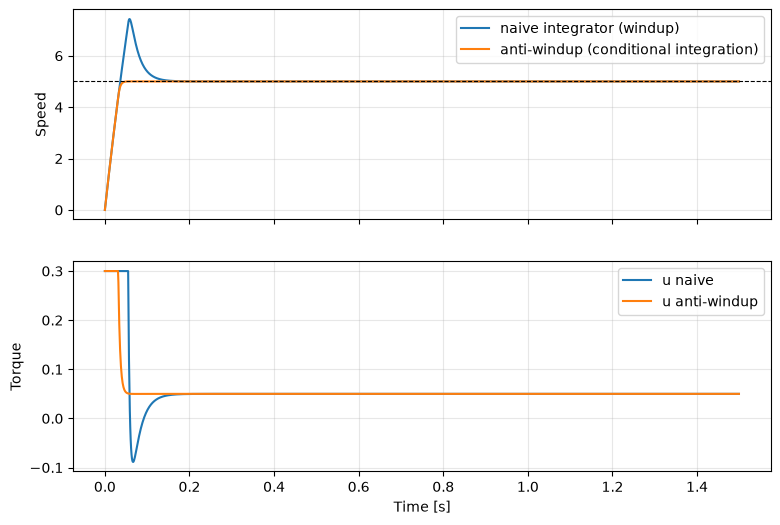

overshoot:naive 2.428 rad/s | anti-windup 0.002 rad/s


In [2]:
# --- 實驗 1:積分器 windup ---
J, b = 0.002, 0.01
fs = 1000.0
dt = 1 / fs
n = int(1.5 / dt)
t = np.arange(n) * dt
u_max = 0.3                               # 轉矩飽和 ±0.3 Nm
target = 5.0                              # 大步階 → 飽和很久

def run_windup(anti_windup):
    plant = MotorPlant(J=J, b=b, dt=dt)
    ctrl = DiscretePID(kp=0.5, ki=20.0, dt=dt,
                       out_min=-u_max, out_max=u_max, anti_windup=anti_windup)
    y, u = np.empty(n), np.empty(n)
    for k in range(n):
        y[k] = plant.w
        u[k] = ctrl.step(target - plant.w)
        plant.step(u[k])
    return y, u

y_naive, u_naive = run_windup(False)
y_aw, u_aw = run_windup(True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(t, y_naive, label='naive integrator (windup)')
ax1.plot(t, y_aw, label='anti-windup (conditional integration)')
ax1.axhline(target, color='k', ls='--', lw=0.8)
ax1.set_ylabel('Speed'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(t, u_naive, label='u naive'); ax2.plot(t, u_aw, label='u anti-windup')
ax2.set_ylabel('Torque'); ax2.set_xlabel('Time [s]'); ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

os_naive = float(y_naive.max() - target)
os_aw = float(y_aw.max() - target)
print(f'overshoot:naive {os_naive:.3f} rad/s | anti-windup {os_aw:.3f} rad/s')

飽和期間 naive 積分器持續累積,解除飽和後必須「吐回」多餘的積分量 → 大幅 overshoot。
anti-windup 在輸出飽和且誤差同向時凍結積分器。

## 實驗 2:庫倫摩擦的零速死區

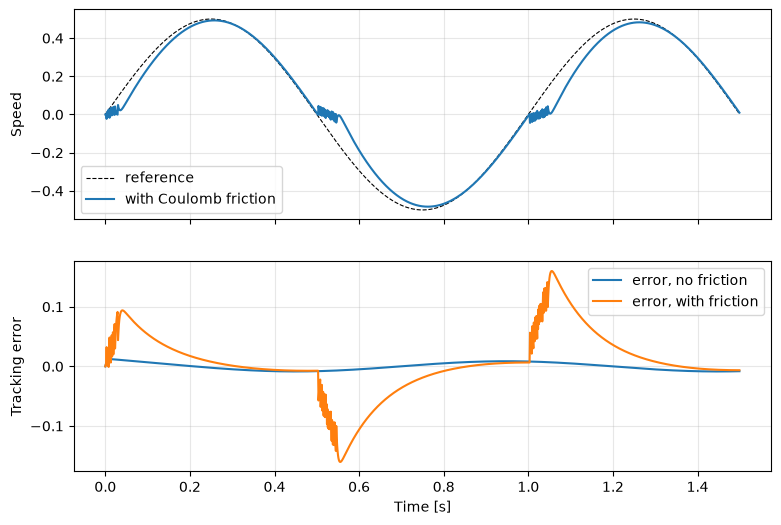

最大追蹤誤差:無摩擦 0.0086 | 有摩擦 0.1604


In [3]:
w_ref = 0.5 * np.sin(2 * np.pi * 1.0 * t)
fc_friction = 0.05                        # 庫倫摩擦轉矩 [Nm]

def run_friction(fc):
    plant = MotorPlant(J=J, b=b, dt=dt)
    ctrl = DiscretePID(kp=0.5, ki=5.0, dt=dt)
    y = np.empty(n)
    for k in range(n):
        y[k] = plant.w
        u = ctrl.step(w_ref[k] - plant.w)
        plant.step(u, t_dist=coulomb(plant.w, fc))
    return y

y_nofric = run_friction(0.0)
y_fric = run_friction(fc_friction)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(t, w_ref, 'k--', lw=0.8, label='reference')
ax1.plot(t, y_fric, label='with Coulomb friction')
ax1.set_ylabel('Speed'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(t, w_ref - y_nofric, label='error, no friction')
ax2.plot(t, w_ref - y_fric, label='error, with friction')
ax2.set_ylabel('Tracking error'); ax2.set_xlabel('Time [s]')
ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

err_fric = np.abs(w_ref - y_fric)[int(0.3/dt):]
err_nof = np.abs(w_ref - y_nofric)[int(0.3/dt):]
print(f'最大追蹤誤差:無摩擦 {err_nof.max():.4f} | 有摩擦 {err_fric.max():.4f}')

誤差尖峰出現在**速度過零**處:摩擦轉矩瞬間反向 ±0.05 Nm,積分器需要時間重建輸出。

## 實驗 3:背隙(backlash)

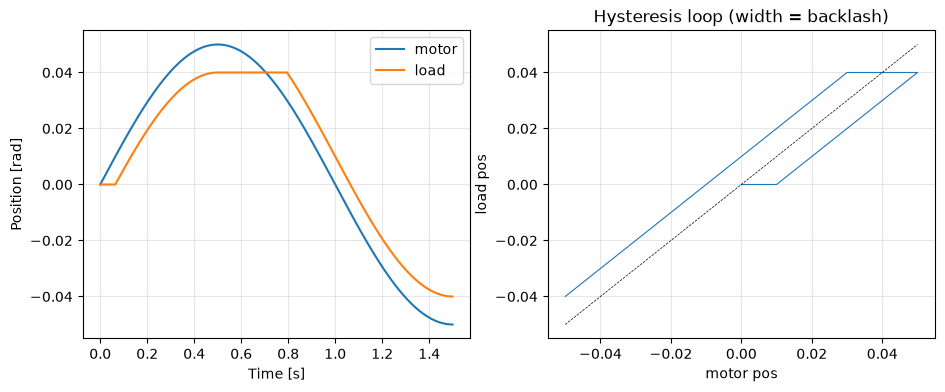

失動量範圍:[-0.0100, 0.0100](理論 ±0.01rad)


In [4]:
bl = Backlash(width=0.02)                 # 總失動量 0.02 rad
motor_pos = 0.05 * np.sin(2 * np.pi * 0.5 * t)
load_pos = np.array([bl.step(x) for x in motor_pos])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(t, motor_pos, label='motor')
ax1.plot(t, load_pos, label='load')
ax1.set_xlabel('Time [s]'); ax1.set_ylabel('Position [rad]'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(motor_pos, load_pos, lw=0.8)
ax2.plot([-0.05, 0.05], [-0.05, 0.05], 'k--', lw=0.5)
ax2.set_xlabel('motor pos'); ax2.set_ylabel('load pos'); ax2.grid(alpha=0.3)
ax2.set_title('Hysteresis loop (width = backlash)')
plt.show()

gap = motor_pos - load_pos
print(f'失動量範圍:[{gap.min():.4f}, {gap.max():.4f}](理論 ±{0.01}rad)')

In [5]:
# ✅ 驗證
assert os_naive > 2 * max(os_aw, 0.05)            # windup 惡化 overshoot
assert os_aw < 0.5
assert np.all(np.abs(u_naive) <= u_max + 1e-9)    # 飽和確實生效
assert err_fric.max() > 3 * err_nof.max()         # 摩擦造成明顯誤差尖峰
zc = np.nonzero(np.diff(np.sign(w_ref[int(0.3/dt):])))[0]
peak_idx = int(np.argmax(err_fric))
assert np.min(np.abs(peak_idx - zc)) < int(0.15 / dt)  # 尖峰靠近速度過零
assert abs(gap.max() - 0.01) < 1e-3 and abs(gap.min() + 0.01) < 1e-3
print('Ch12 驗證通過 ✅')

Ch12 驗證通過 ✅


## 練習
1. 把 anti-windup 改成 back-calculation(u 超限時把積分器往回拉),與條件積分比較。
2. 摩擦補償:偵測速度方向、前饋 +fc·sign(w_ref),誤差尖峰能壓多少?殘餘問題在哪?
3. 把 backlash 放進**位置閉迴路**(回授取 load 端),觀察極限循環(limit cycle)出現的增益。
4. 時變性:讓 J 在 1 秒內線性變成 2 倍(例如機械手臂伸展),固定增益的迴路表現如何?